# 03 — Is one acquisition channel better than another? (Part 3)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

from db import run_query, close
from style import BLUE, ORANGE, AQUA, INK_2, MUTED, GREYS, save

pd.set_option("display.width", 140)
CHANNELS = ["organic", "paid_social", "paid_video"]

In [2]:
base = run_query("""
    SELECT p.device_id, p.install_date, p.acquisition_channel AS channel, p.country_tier AS tier,
           p.platform, DATE_FORMAT(p.install_date, '%Y-%m') AS install_month,
           EXISTS (SELECT 1 FROM player_day d WHERE d.device_id = p.device_id
                   AND d.activity_dt = p.install_date + INTERVAL 7 DAY) AS d7,
           COALESCE((SELECT SUM(pc.usd_amount) FROM purchase_clean pc
                     WHERE pc.device_id = p.device_id AND pc.usd_amount > 0
                       AND pc.event_dt < p.install_date + INTERVAL 30 DAY), 0) AS rev30
    FROM player_profile p
    WHERE p.install_date BETWEEN '2026-01-01' AND '2026-03-31'
""")
base["d7"] = base["d7"].astype(int)
base["payer30"] = (base.rev30 > 0).astype(int)
print(len(base), "installs;", base.device_id.is_unique, "unique")
display(base.groupby("channel").size().rename("installs").to_frame())

37489 installs; True unique


,installs
channel,
organic,12948
paid_social,11511
paid_video,13030


In [3]:
raw = base.groupby("channel").agg(installs=("device_id", "size"), d7=("d7", "mean"),
                                  rev30=("rev30", "mean"), payer30=("payer30", "mean"))
display(raw.style.format({"d7": "{:.2%}", "rev30": "${:.3f}", "payer30": "{:.2%}"}))

,installs,d7,rev30,payer30
channel,,,,
organic,12948,26.39%,$2.492,13.43%
paid_social,11511,25.58%,$2.240,13.26%
paid_video,13030,24.56%,$1.568,8.97%


In [4]:
mix_tier = pd.crosstab(base.channel, base.tier, normalize="index")
mix_month = pd.crosstab(base.channel, base.install_month, normalize="index")
mix_plat = pd.crosstab(base.channel, base.platform, normalize="index")
display(mix_tier.round(3)); display(mix_month.round(3)); display(mix_plat.round(3))

by_tier = base.groupby("tier").agg(rev30=("rev30", "mean"), d7=("d7", "mean"))
display(by_tier.round(3))

tier,1,2,3,4
channel,,,,
organic,0.338,0.257,0.222,0.183
paid_social,0.345,0.253,0.218,0.184
paid_video,0.110,0.085,0.152,0.653


install_month,2026-01,2026-02,2026-03
channel,,,
organic,0.347,0.310,0.343
paid_social,0.333,0.320,0.347
paid_video,0.114,0.136,0.750


platform,Android,iOS
channel,,
organic,0.632,0.368
paid_social,0.638,0.362
paid_video,0.795,0.205


,rev30,d7
tier,,
1,3.530,0.258
2,2.290,0.267
3,1.748,0.258
4,1.098,0.244


In [5]:
within = base.groupby(["tier", "channel"]).agg(installs=("device_id", "size"), d7=("d7", "mean"),
                                               rev30=("rev30", "mean"), payer30=("payer30", "mean"))
display(within.style.format({"d7": "{:.2%}", "rev30": "${:.3f}", "payer30": "{:.2%}"}))

In [6]:
weights = base.tier.value_counts(normalize=True).sort_index()
cells = {(c, t, m): base.loc[(base.channel == c) & (base.tier == t), m].to_numpy(float)
         for c in CHANNELS for t in weights.index for m in ("d7", "rev30", "payer30")}


def standardised(channel, metric):
    return sum(w * cells[(channel, t, metric)].mean() for t, w in weights.items())


def boot_standardised(channel, metric, rng, n_boot=5000):
    out = np.zeros(n_boot)
    for t, w in weights.items():
        x = cells[(channel, t, metric)]
        idx = rng.integers(0, len(x), size=(n_boot, len(x)))
        out += w * x[idx].mean(axis=1)
    return out


rng = np.random.default_rng(42)
boots = {(c, m): boot_standardised(c, m, rng) for c in CHANNELS for m in ("d7", "rev30", "payer30")}

std = pd.DataFrame({m: {c: standardised(c, m) for c in CHANNELS} for m in ("d7", "rev30", "payer30")})
display(pd.concat([raw[["d7", "rev30", "payer30"]].add_prefix("raw_"), std.add_prefix("std_")], axis=1)
        .style.format("{:.4f}"))

rows = []
for a, b in [("organic", "paid_social"), ("organic", "paid_video"), ("paid_social", "paid_video")]:
    for m in ("d7", "rev30", "payer30"):
        diff = boots[(a, m)] - boots[(b, m)]
        rows.append({"comparison": f"{a} − {b}", "metric": m,
                     "raw_diff": raw.loc[a, m] - raw.loc[b, m],
                     "std_diff": standardised(a, m) - standardised(b, m),
                     "ci_low": np.percentile(diff, 2.5), "ci_high": np.percentile(diff, 97.5),
                     "p_boot": min(1.0, 2 * min((diff <= 0).mean(), (diff >= 0).mean()))})
inf = pd.DataFrame(rows)
d7 = inf.metric == "d7"
inf.loc[d7, "p_holm"] = multipletests(inf.loc[d7, "p_boot"], method="holm")[1]
display(inf.round(4))

,raw_d7,raw_rev30,raw_payer30,std_d7,std_rev30,std_payer30
organic,0.2639,2.4918,0.1343,0.2586,2.1716,0.1208
paid_social,0.2558,2.2399,0.1326,0.2535,1.9771,0.1187
paid_video,0.2456,1.5681,0.0897,0.2451,2.0662,0.1138


,comparison,metric,raw_diff,std_diff,ci_low,ci_high,p_boot,p_holm
0,organic − paid_social,d7,0.0081,0.0051,-0.0067,0.0166,0.4156,0.4156
1,organic − paid_social,rev30,0.2520,0.1945,-0.0560,0.4447,0.1300,NaN
2,organic − paid_social,payer30,0.0017,0.0022,-0.0061,0.0104,0.6036,NaN
3,organic − paid_video,d7,0.0183,0.0135,0.0014,0.0256,0.0276,0.0828
4,organic − paid_video,rev30,0.9237,0.1054,-0.2099,0.4120,0.4980,NaN
5,organic − paid_video,payer30,0.0446,0.0071,-0.0020,0.0161,0.1296,NaN
6,paid_social − paid_video,d7,0.0103,0.0084,-0.0043,0.0212,0.1856,0.3712
7,paid_social − paid_video,rev30,0.6718,-0.0891,-0.4063,0.2208,0.5572,NaN
8,paid_social − paid_video,payer30,0.0429,0.0049,-0.0042,0.0144,0.3008,NaN


In [7]:
w2 = base.groupby(["tier", "install_month"]).size() / len(base)
std2 = {}
for c in CHANNELS:
    g = base[base.channel == c].groupby(["tier", "install_month"])[["d7", "rev30"]].mean()
    std2[c] = (g.mul(w2, axis=0)).sum()
display(pd.DataFrame(std2).T.round(4))

,d7,rev30
organic,0.2568,2.1612
paid_social,0.2522,2.0730
paid_video,0.2456,2.0637


In [8]:
for a, b in [("organic", "paid_video"), ("paid_social", "paid_video"), ("organic", "paid_social")]:
    se_rev = (boots[(a, "rev30")] - boots[(b, "rev30")]).std()
    se_d7 = (boots[(a, "d7")] - boots[(b, "d7")]).std()
    print(f"{a:>11} vs {b:<11}  MDE revenue ≈ ${2.8 * se_rev:.2f}/install "
          f"({2.8 * se_rev / standardised(b, 'rev30'):.0%} of {b})   MDE D7 ≈ {2.8 * se_d7 * 100:.1f} pts")

    organic vs paid_video   MDE revenue ≈ $0.45/install (22% of paid_video)   MDE D7 ≈ 1.7 pts
paid_social vs paid_video   MDE revenue ≈ $0.45/install (22% of paid_video)   MDE D7 ≈ 1.8 pts
    organic vs paid_social  MDE revenue ≈ $0.36/install (18% of paid_social)   MDE D7 ≈ 1.7 pts


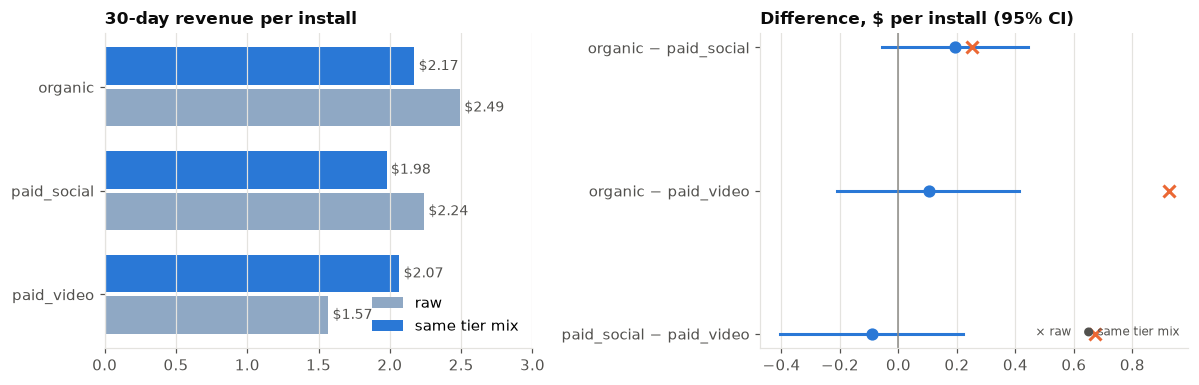

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
y = np.arange(len(CHANNELS))
ax.barh(y + 0.2, raw.loc[CHANNELS, "rev30"], height=0.36, color=GREYS[2], label="raw")
ax.barh(y - 0.2, std.loc[CHANNELS, "rev30"], height=0.36, color=BLUE, label="same tier mix")
for i, c in enumerate(CHANNELS):
    ax.text(raw.loc[c, "rev30"] + 0.03, i + 0.2, f"${raw.loc[c, 'rev30']:.2f}", va="center", fontsize=9, color=INK_2)
    ax.text(std.loc[c, "rev30"] + 0.03, i - 0.2, f"${std.loc[c, 'rev30']:.2f}", va="center", fontsize=9, color=INK_2)
ax.set_yticks(y); ax.set_yticklabels(CHANNELS); ax.invert_yaxis()
ax.set_xlim(0, 3)
ax.set_title("30-day revenue per install")
ax.legend(loc="lower right")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)

ax = axes[1]
sub = inf[inf.metric == "rev30"].reset_index(drop=True)
for i, r in sub.iterrows():
    ax.plot([r.ci_low, r.ci_high], [i, i], color=BLUE, lw=2)
    ax.plot(r.std_diff, i, "o", color=BLUE, ms=7)
    ax.plot(r.raw_diff, i, "x", color=ORANGE, ms=8, mew=2)
ax.axvline(0, color=MUTED, lw=1)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub.comparison); ax.invert_yaxis()
ax.set_title("Difference, $ per install (95% CI)")
ax.text(0.98, 0.04, "× raw   ● same tier mix", transform=ax.transAxes, ha="right", fontsize=8, color=INK_2)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "p3_channels")
plt.show()

## Final Interpretation

The raw comparison suggests that paid_video generates substantially less 30-day revenue per install, but this is largely a **mix effect**: about **65% of paid_video installs are Tier 4**, compared with about 18% for organic and paid_social, and Tier 4 has lower revenue per install regardless of channel.

After standardising all channels to the same tier mix, 30-day revenue differences are small: the largest point estimate is about **$0.19 per install**, and all 95% CIs include zero. Controlling for install month produces nearly the same estimates, so the conclusion is not driven by the March acquisition spike.

For D7 retention, organic is **1.35 percentage points** above paid_video in the standardized comparison. The unadjusted bootstrap p-value is about **0.028**, but the Holm-adjusted p-value is **0.083**; this is therefore a small difference that is not robust to multiple-comparison correction. The revenue sample can reliably detect only differences of roughly **$0.36–$0.45 per install**, so smaller revenue differences are difficult to resolve with this window.

**Action:** The telemetry does not support shifting paid acquisition based on channel quality alone. For paid_social vs paid_video, compare **tier-matched CPI against tier-matched value** and validate any meaningful change with an incremental/holdout test. Longer-horizon revenue and reliable attribution would improve the decision.

In [10]:
close()